In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.2 MB/s eta 0:00:00


In [ ]:
!pip install datasets

In [ ]:
# Download just a few sample images from AP-10K via gdown (Google Drive)
!pip install gdown

# Official AP-10K download (annotations + images)
!gdown --fuzzy "https://drive.google.com/file/d/1-FNNGcdtAQRehYYkGY1y4wzFNg4iWNad/view" -O /content/ap10k.zip
!unzip -q /content/ap10k.zip -d /content/ap10k

Downloading...
From (original): https://drive.google.com/uc?id=1-FNNGcdtAQRehYYkGY1y4wzFNg4iWNad
From (redirected): https://drive.google.com/uc?id=1-FNNGcdtAQRehYYkGY1y4wzFNg4iWNad&confirm=t&uuid=6d4a42e1-6e12-4cf1-8f33-bc3b18988f95
To: /content/ap10k.zip
100% 3.40G/3.40G [00:35<00:00, 97.1MB/s]


In [ ]:
import os
for root, dirs, files in os.walk('/content/ap10k'):
    for f in files:
        print(os.path.join(root, f))

/content/ap10k/ap-10k/data/000000056589.jpg
/content/ap10k/ap-10k/data/000000055818.jpg
/content/ap10k/ap-10k/data/000000020592.jpg
/content/ap10k/ap-10k/data/000000055864.jpg
/content/ap10k/ap-10k/data/000000056688.jpg
/content/ap10k/ap-10k/data/000000009404.jpg
/content/ap10k/ap-10k/data/000000039817.jpg
/content/ap10k/ap-10k/data/000000047503.jpg
/content/ap10k/ap-10k/data/000000046295.jpg
/content/ap10k/ap-10k/data/000000035550.jpg
/content/ap10k/ap-10k/data/000000018416.jpg
/content/ap10k/ap-10k/data/000000002025.jpg
/content/ap10k/ap-10k/data/000000045087.jpg
/content/ap10k/ap-10k/data/000000048770.jpg
/content/ap10k/ap-10k/data/000000045075.jpg
/content/ap10k/ap-10k/data/000000020228.jpg
/content/ap10k/ap-10k/data/000000009396.jpg
/content/ap10k/ap-10k/data/000000018301.jpg
/content/ap10k/ap-10k/data/000000056670.jpg
/content/ap10k/ap-10k/data/000000037643.jpg
/content/ap10k/ap-10k/data/000000012652.jpg
/content/ap10k/ap-10k/data/000000019641.jpg
/content/ap10k/ap-10k/data/00000

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/ap10k/ap-10k/data/000000056589.jpg: 480x640 (no detections), 454.6ms
Speed: 34.2ms preprocess, 454.6ms inference, 22.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/output/zeroshot


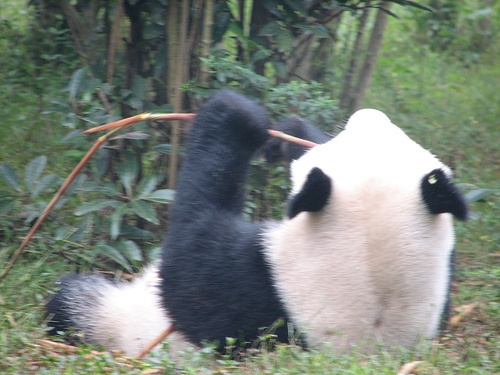

In [ ]:
from ultralytics import YOLO
from IPython.display import Image as IPImage
import os

model = YOLO('yolov8n-pose.pt')

# running on a sample image from dataset
sample = '/content/ap10k/ap-10k/data/000000056589.jpg'

results = model(sample, save=True, project='/content/output', name='zeroshot')

IPImage(filename='/content/output/zeroshot/000000056589.jpg')

Running inference on 1000 images...
  0/1000...
  100/1000...
  200/1000...
  300/1000...
  400/1000...
  500/1000...
  600/1000...
  700/1000...
  800/1000...
  900/1000...
Done! Plotting results...


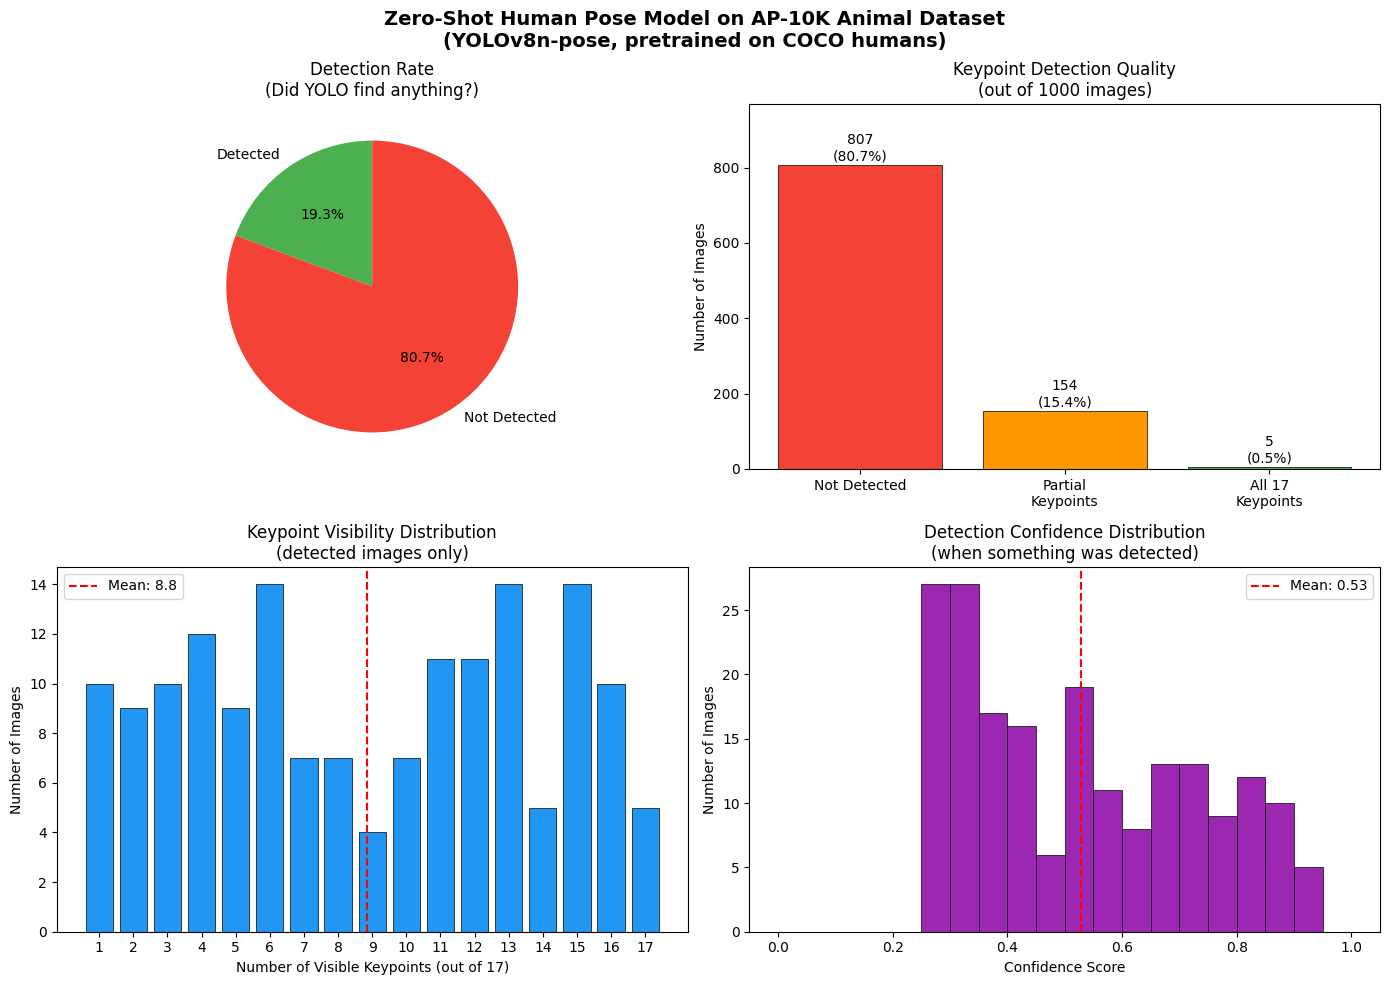


ZERO-SHOT EXPERIMENT SUMMARY (n=1000)
Detection rate:        19.3%
No detection:          80.7%
All 17 kpts visible:   0.5%
Partial kpts visible:  15.4%
Mean confidence:       0.53
Mean visible kpts:     8.8 / 17


In [ ]:
from ultralytics import YOLO
from IPython.display import Image as IPImage
import os, json, random
import matplotlib.pyplot as plt
import numpy as np

model = YOLO('yolov8n-pose.pt')

# Get 1000 random images
img_dir = '/content/ap10k/ap-10k/data'
all_images = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith('.jpg')]
sample_images = random.sample(all_images, 1000)

# Run inference and collect stats
results_data = {
    'detected': 0,        # YOLO found at least one person/animal
    'not_detected': 0,    # YOLO found nothing
    'keypoints_full': 0,  # All 17 keypoints visible
    'keypoints_partial': 0, # Some keypoints visible
    'confidence_scores': [],
    'keypoints_per_image': [],
    'visible_keypoints_per_image': []
}

print("Running inference on 1000 images...")
for i, img_path in enumerate(sample_images):
    if i % 100 == 0:
        print(f"  {i}/1000...")

    result = model(img_path, verbose=False)[0]

    if result.keypoints is None or len(result.keypoints) == 0:
        results_data['not_detected'] += 1
        results_data['keypoints_per_image'].append(0)
        results_data['visible_keypoints_per_image'].append(0)
    else:
        results_data['detected'] += 1

        # Get best detection (highest confidence)
        if result.boxes is not None and len(result.boxes) > 0:
            conf = float(result.boxes.conf[0])
            results_data['confidence_scores'].append(conf)

        # Count visible keypoints (confidence > 0.5)
        kpts = result.keypoints.data[0]  # shape [17, 3]
        visible = int((kpts[:, 2] > 0.5).sum())
        results_data['keypoints_per_image'].append(17)
        results_data['visible_keypoints_per_image'].append(visible)

        if visible == 17:
            results_data['keypoints_full'] += 1
        elif visible > 0:
            results_data['keypoints_partial'] += 1

print("Done! Plotting results...")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Zero-Shot Human Pose Model on AP-10K Animal Dataset\n(YOLOv8n-pose, pretrained on COCO humans)',
             fontsize=14, fontweight='bold')

# 1. Detection rate pie chart
ax1 = axes[0, 0]
labels = ['Detected', 'Not Detected']
sizes = [results_data['detected'], results_data['not_detected']]
colors = ['#4CAF50', '#F44336']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Detection Rate\n(Did YOLO find anything?)')

# 2. Keypoint visibility breakdown (bar chart)
ax2 = axes[0, 1]
categories = ['Not Detected', 'Partial\nKeypoints', 'All 17\nKeypoints']
counts = [results_data['not_detected'], results_data['keypoints_partial'], results_data['keypoints_full']]
colors2 = ['#F44336', '#FF9800', '#4CAF50']
bars = ax2.bar(categories, counts, color=colors2, edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/10:.1f}%)', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Number of Images')
ax2.set_title('Keypoint Detection Quality\n(out of 1000 images)')
ax2.set_ylim(0, max(counts) * 1.2)

# 3. Histogram of visible keypoints per detected image
ax3 = axes[1, 0]
visible_kpts = [v for v in results_data['visible_keypoints_per_image'] if v > 0]
if visible_kpts:
    ax3.hist(visible_kpts, bins=17, range=(0.5, 17.5), color='#2196F3',
             edgecolor='black', linewidth=0.5, rwidth=0.8)
ax3.set_xlabel('Number of Visible Keypoints (out of 17)')
ax3.set_ylabel('Number of Images')
ax3.set_title('Keypoint Visibility Distribution\n(detected images only)')
ax3.set_xticks(range(1, 18))
ax3.axvline(x=np.mean(visible_kpts) if visible_kpts else 0,
            color='red', linestyle='--', label=f'Mean: {np.mean(visible_kpts):.1f}' if visible_kpts else '')
ax3.legend()

# 4. Confidence score distribution
ax4 = axes[1, 1]
if results_data['confidence_scores']:
    ax4.hist(results_data['confidence_scores'], bins=20, range=(0, 1),
             color='#9C27B0', edgecolor='black', linewidth=0.5)
    ax4.axvline(x=np.mean(results_data['confidence_scores']),
                color='red', linestyle='--',
                label=f'Mean: {np.mean(results_data["confidence_scores"]):.2f}')
    ax4.legend()
ax4.set_xlabel('Confidence Score')
ax4.set_ylabel('Number of Images')
ax4.set_title('Detection Confidence Distribution\n(when something was detected)')

plt.tight_layout()
plt.savefig('/content/zero_shot_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"\n{'='*50}")
print(f"ZERO-SHOT EXPERIMENT SUMMARY (n=1000)")
print(f"{'='*50}")
print(f"Detection rate:        {results_data['detected']/10:.1f}%")
print(f"No detection:          {results_data['not_detected']/10:.1f}%")
print(f"All 17 kpts visible:   {results_data['keypoints_full']/10:.1f}%")
print(f"Partial kpts visible:  {results_data['keypoints_partial']/10:.1f}%")
if results_data['confidence_scores']:
    print(f"Mean confidence:       {np.mean(results_data['confidence_scores']):.2f}")
if visible_kpts:
    print(f"Mean visible kpts:     {np.mean(visible_kpts):.1f} / 17")